In [1]:
# testrun = "false"
testrun = True
version = "4_test"
write_out = False

In [2]:
print(testrun)

True


# Evaluate with GPT-4

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import pickle


In [5]:
import pandas as pd

In [6]:
import re
import openai
import pandas as pd
import random


import sys
import os
import tiktoken
from tenacity import (
    retry,
    stop_after_attempt,
    wait_random_exponential,
)  # for exponential backoff

In [7]:
from langchain_openai import AzureChatOpenAI
	
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.memory import ChatMessageHistory

from langchain.prompts.chat import ChatPromptTemplate
from langchain_core.runnables.history import RunnableWithMessageHistory

from langchain.prompts.chat import ChatPromptTemplate, HumanMessagePromptTemplate

In [8]:
from brush_llm_funcs import brush_prepost_prob_llm, brush_get_probs_from_llm, brush_get_llm_responses
from llm_funcs import compute_true_bayesian_update

In [9]:
%load_ext dotenv
%dotenv /vast/palmer/home.mccleary/vs428/Documents/DischargeMe/hail-dischargeme/.env

In [10]:
engine = "decile-gpt-4-128K"

In [11]:
os.environ['AZURE_OPENAI_ENDPOINT'] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ['AZURE_OPENAI_API_KEY'] = os.getenv("AZURE_OPENAI_KEY")
os.environ["OPENAI_API_VERSION"] = "2023-12-01-preview"

In [4]:
import pandas as pd
data = pd.read_csv("/home/vs428/project/Uncertainty_data/all_cases_clean.csv", sep="|",  engine="c")

In [11]:
prompts = pd.read_csv("prompts.csv")

In [27]:
print(prompts.sample(1)['prompt_template'].squeeze())

{labresult}

{question2} Let's think step by step. First, explain your reasoning, and then give your answer. {format_instructions}


In [15]:
data['case'] = data['case'].str.replace("“", '"')
data['case'] = data['case'].str.replace("”", '"')
data['case'] = data['case'].str.replace("’", "'")
data['case'] = data['case'].str.replace("½", "1/2")
data['case'] = data['case'].str.replace("–", "-")

In [16]:
for case in data['case'].tolist():
    try:
        case.encode('ascii')
    except UnicodeDecodeError:
        print("it was not a ascii-encoded unicode string")

In [17]:
with pd.option_context("display.max_colwidth", 2000):
    display(data.sample(5))

,index,case_id,case_type,probability,differential,case,lab_value_text,q1,q2,pos_lr,neg_lr
39,39,10,Pulmonary Embolism,high,PE,"An 86 year old women presents from home post syncopal event. She describes increasing breathlessness for the past week. She also complains of posterior chest pain that she describes as constant and sharp. The syncopal event happened as she was walking from the kitchen into her living room. She does not report any injury as a result of the fall. But she does remark that it feels as if her heart is still racing and that she can't breathe. You note that while she is speaking full sentences she does appear breathless.\n\nThe patient's past medical history is remarkable for locally metastatic colon cancer. This has only recently been diagnosed. She is to begin adjuvant chemotherapy next week to reduce tumour burden prior surgical resection. She has no cardiac history and is otherwise healthy.\n\nOn examination, her temperature is 37.2, pulse 125, BP 90/56, and RR 28. Her chest is clear to auscultation. Her cardiac exam reveals normal bilateral pulses and blood pressure. She has no murmurs or extra heart sounds, although the heart rate is noted to be elevated and regular. There is no evidence of head or extremity injury on physical exam as a result of the fall.",A quantitative D-dimer is measured. The value is < > which is reported as <>. Studies show that a quantitative d-dimer is predictive of pulmonary embolism with a sensitivity of 96% and a specificity of 45% with a positive likelihood ratio of 1.7 and a negative likelihood ratio of 0.09.,What is the probability that this patient has a pulmonary embolism?,What is the probability that this patient has a pulmonary embolism?,1.70,0.09
37,37,8,Pulmonary Embolism,medium,PE v Pneumonia,"A 54-year old woman presents to the emergency department after a sudden attack of shortness of breath. This dyspnea was accompanied by retrosternal chest pain, which was worse on deep breathing. She has otherwise been feeling well this week other than a cough productive of clear or yellow sputum for several days, and had three episodes in which she coughed up small amounts of blood. The patient complained of nausea and vomited a small amount of what appeared to be remnants of her dinner when driving to the hospital. She travels frequently for work, and recently returned from a conference that required a number of connecting flights to get home. She complains of feeling exhausted.\n\nHer past medical history is remarkable for a renal transplant. She is on triple immune suppression (prednisone, tacrolimus and cyclosporine). She has had pneumonia in the past as a complication of her drug therapy. She smokes occasionally when in social settings and drinks 1 glass of wine daily. She does not use illicit drugs. \n\nOn examination, her temperature is 38.2, pulse 106, BP 110/96, and RR 22. Her oropharynx has no erythema or exudate. Her chest is resonant to percussion bilaterally with faint crackles auscultated at her left lung base. Her heart demonstrates regular rate and rhythm, with a 2/6 holosystolic murmur heard loudest at the apex without radiation.",A quantitative D-dimer is measured. The value is < > which is reported as <>. Studies show that a quantitative d-dimer is predictive of pulmonary embolism with a sensitivity of 96% and a specificity of 45% with a positive likelihood ratio of 1.7 and a negative likelihood ratio of 0.09.,What is the probability that this patient has a pulmonary embolism?,What is the probability that this patient has a pulmonary embolism?,1.70,0.09
8,8,9,ACS,medium,ACS versus CAD plus musculoskeletal,"A 70 year-old woman presents to the ED with chest pain. She has a history of coronary artery disease and underwent CABG x 4 8 years ago. Since then, she has done fairly well. She was working in her yard over the weekend, raking leaves. The next day, she noted a sharp pain in her chest that has recurred several times since then. This morning, when she awoke

In [18]:
llm = AzureChatOpenAI(
    deployment_name=engine
)

In [19]:
if testrun == True:
    data = data.iloc[27:30].reset_index(drop=True)

# Run model

## Setup LangChain LLM Pipeline

In [20]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an expert physician estimating your confidence that a patient has a particular disease using only the clinical presentation you're reading.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

chain = prompt | llm

In [21]:
pretest_template = "{case}\n\n{question1} Let's think step by step. First, explain your reasoning, and then give your answer. {format_instructions}"

posttest_template = "{labresult}\n\n{question2} Let's think step by step. First, explain your reasoning, and then give your answer. {format_instructions}"

In [22]:
format_instructions = "Your response should be a SINGLE numerical probability estimate in the form of `The likelihood of [condition] is [number]%.` DO NOT give a range."

## Negative Lab Results

In [23]:
data['case_type'].value_counts()

case_type
PNEUMONIA    3
Name: count, dtype: int64

In [24]:
neg_chat_histories = brush_prepost_prob_llm(chain, data,
                       pretest_template, posttest_template, format_instructions, 
                       positive=False,
                       verbose=False)


Current row: 0
Current row: 1
Current row: 2


In [25]:
if write_out:
    pickle.dump(neg_chat_histories, open(f"neg_chat_histories_{version}.pickle", "wb" ) )
# neg_chat_histories = pickle.load(open(f"neg_chat_histories.pickle", "rb"))

In [26]:
neg_pretest_probs, neg_posttest_probs = brush_get_probs_from_llm(neg_chat_histories)

In [27]:
neg_pretest_responses, neg_posttest_responses = brush_get_llm_responses(neg_chat_histories)

In [28]:
neg_probs_df = pd.DataFrame({"pretest_prob":neg_pretest_probs, "posttest_prob":neg_posttest_probs})

In [29]:
neg_response_df = pd.DataFrame({"pretest_llm_output":neg_pretest_responses, "posttest_llm_output":neg_posttest_responses})

In [30]:
neg_data_with_gpt = pd.concat([data, neg_probs_df, neg_response_df],axis=1)

In [31]:
# drop the respsective pneumonia cases (either positive or negative), since these were also hard-coded xray interpretations and not filled in
# neg_data_with_gpt = neg_data_with_gpt[~((neg_data_with_gpt['differential'] == "Asthma Exacerbation v CAP")
#                                         & (neg_data_with_gpt['case_type'] == "PNEUMONIA"))]

# neg_data_with_gpt = neg_data_with_gpt[~((neg_data_with_gpt['differential'] == "HCAP")
#                                         & (neg_data_with_gpt['case_type'] == "PNEUMONIA"))]
# negative: URI
# negative: PCP v ILI
# positive: Asthma Exacerbation v CAP
# positive: HCAP

neg_data_with_gpt['true_posttest'] = neg_data_with_gpt.apply(lambda row: compute_true_bayesian_update(row['pretest_prob']/100, row['neg_lr']) * 100, axis=1)

neg_data_with_gpt['positive'] = False

In [32]:
if write_out:
    neg_data_with_gpt.to_csv(f"all_cases_neg_gpt4_output_{version}.csv", index=False)

## Positive Lab Results

In [33]:
pos_chat_histories = brush_prepost_prob_llm(chain, data, 
                       pretest_template, posttest_template, format_instructions, 
                       positive=True,
                       verbose=False)


Current row: 0
Current row: 1
Current row: 2


In [34]:
if write_out:
    pickle.dump(pos_chat_histories, open(f"pos_chat_histories_{version}.pickle", "wb" ) )
# pos_chat_histories = pickle.load(open(f"pos_chat_histories.pickle", "rb"))

In [35]:
pos_pretest_probs, pos_posttest_probs = brush_get_probs_from_llm(pos_chat_histories)

In [36]:
pos_pretest_responses, pos_posttest_responses = brush_get_llm_responses(pos_chat_histories)

In [37]:
pos_probs_df = pd.DataFrame({"pretest_prob":pos_pretest_probs, "posttest_prob":pos_posttest_probs})

In [38]:
pos_response_df = pd.DataFrame({"pretest_llm_output": pos_pretest_responses, "posttest_llm_output": pos_posttest_responses})

In [39]:
pos_data_with_gpt = pd.concat([data, pos_probs_df, pos_response_df],axis=1)

In [40]:
# drop the Pulmonary Embolism test cases from the positive lab df, since they have hard coded "negative" d-dimer values
# pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['probability'] == "low")
# & (pos_data_with_gpt['case_type'] == "Pulmonary Embolism"))]

# drop the respsective pneumonia cases (either positive or negative), since these were also hard-coded xray interpretations and not filled in
# pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['differential'] == "URI")
#                                         & (pos_data_with_gpt['case_type'] == "PNEUMONIA"))]

# pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['differential'] == "PCP v ILI")
#                                         & (pos_data_with_gpt['case_type'] == "PNEUMONIA"))]

# negative: URI
# negative: PCP v ILI
# positive: Asthma Exacerbation v CAP
# positive: HCAP

In [42]:
pos_data_with_gpt['true_posttest'] = pos_data_with_gpt.apply(lambda row: compute_true_bayesian_update(row['pretest_prob']/100, row['pos_lr']) * 100, axis=1)


In [43]:
pos_data_with_gpt['positive'] = True


In [44]:
if write_out:
    pos_data_with_gpt.to_csv(f"all_cases_pos_gpt4_output_{version}.csv", index=False)

# Compute Bayesian Change Score

In [46]:
data_with_gpt = pd.concat([pos_data_with_gpt, neg_data_with_gpt], axis=0)

In [47]:
data_with_gpt['bayes_diff'] = data_with_gpt['true_posttest'] - data_with_gpt['posttest_prob']

In [48]:
if write_out:
    data_with_gpt.to_csv(f"all_cases_posneg_gpt4_output_{version}.csv", index=False)

# Plot

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
results = pd.DataFrame([(neg_data_with_gpt['true_posttest'] - neg_data_with_gpt['posttest_prob']).tolist(), 
                        (pos_data_with_gpt['true_posttest'] - pos_data_with_gpt['posttest_prob']).tolist()]).T.rename({0:"negative test", 
                                                                                                                       1:"positive test"}, 
                                                                                                                      axis=1)

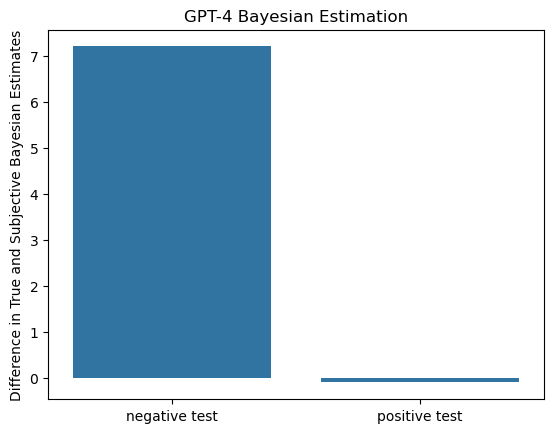

In [52]:
fig = sns.barplot(results.mean(), )
plt.ylabel("Difference in True and Subjective Bayesian Estimates")
plt.title("GPT-4 Bayesian Estimation")
if write_out:
    plt.savefig(f"difference_{version}.png", bbox_inches="tight")
else:
    plt.show()

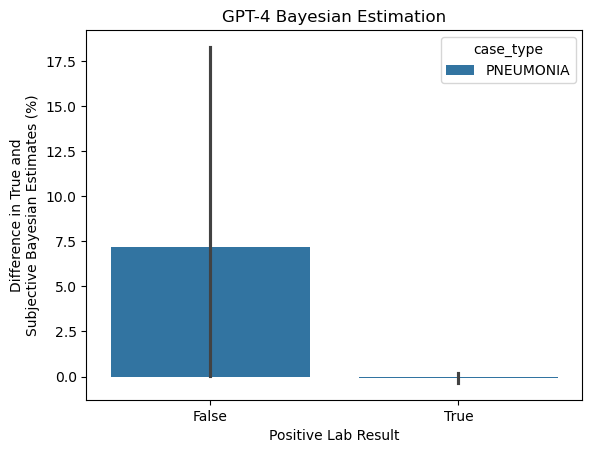

In [53]:
fig = sns.barplot(data_with_gpt, x="positive", y='bayes_diff', hue="case_type")
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.title("GPT-4 Bayesian Estimation")
if write_out:
    plt.savefig(f"difference_by_condition_{version}.png", bbox_inches="tight")
else:
    plt.show()    